2025-09-17 14:30:14.347947: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


正在生成 50000 个32×32矩阵...
数据集生成完成，耗时: 18.72秒
可逆矩阵比例: 28.75%
生成难例样本...
添加特殊奇异模式...
增强后数据集可逆矩阵比例: 28.90%

数据集划分:
训练集: 522800 样本
测试集: 130700 样本

创建模型...


2025-09-17 14:31:04.510888: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-17 14:31:05.383448: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22300 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:8e:00.0, compute capability: 8.6


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 128)  3328        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 32, 32, 128)  512        ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 conv2d_1 (Conv2D)              (None, 32, 32, 256)  295168      ['batch_normalization[0][0]']

2025-09-17 14:31:15.726831: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-09-17 14:31:18.670828: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1736/1736 [==============================] - ETA: 0s - loss: 0.1997 - accuracy: 0.7102 - precision: 0.2692 - recall: 4.3520e-04 - auc: 0.5159 - prc: 0.2990 - specificity: 0.4713
Epoch 1: val_prc improved from -inf to 0.32821, saving model to best_model.h5
1736/1736 [==============================] - 176s 97ms/step - loss: 0.1997 - accuracy: 0.7102 - precision: 0.2692 - recall: 4.3520e-04 - auc: 0.5159 - prc: 0.2990 - specificity: 0.4713 - val_loss: 0.0924 - val_accuracy: 0.7141 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5600 - val_prc: 0.3282 - val_specificity: 0.5573 - lr: 1.0000e-04
Epoch 2/100
1736/1736 [==============================] - ETA: 0s - loss: 0.1528 - accuracy: 0.7104 - precision: 0.4545 - recall: 3.8857e-05 - auc: 0.5561 - prc: 0.3336 - specificity: 0.5718
Epoch 2: val_prc improved from 0.32821 to 0.38790, saving model to best_model.h5
1736/1736 [==============================] - 165s 95ms/step - loss: 0.1528 - accuracy: 0.7104 - precision: 0.4545 

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS


              precision    recall  f1-score   support

         不可逆       0.98      0.99      0.98     92925
          可逆       0.97      0.95      0.96     37775

    accuracy                           0.98    130700
   macro avg       0.97      0.97      0.97    130700
weighted avg       0.98      0.98      0.98    130700



/root/miniconda3/lib/python3.8/site-packages/seaborn/utils.py:61: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  fig.canvas.draw()
/root/miniconda3/lib/python3.8/site-packages/seaborn/utils.py:61: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from current font.
  fig.canvas.draw()
/root/miniconda3/lib/python3.8/site-packages/seaborn/utils.py:61: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from current font.
  fig.canvas.draw()
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial Unicode MS
/tmp/ipykernel_837/3574408920.py:438: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  plt.savefig('confusion_matrix.png', dpi=300)
/tmp/ipykernel_837/3574408920.py:438: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from current

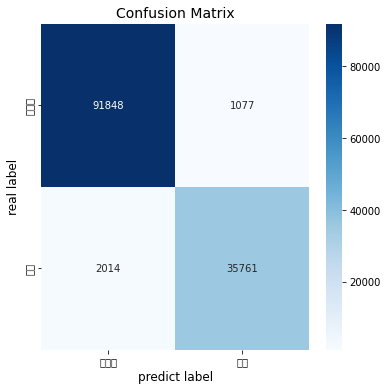

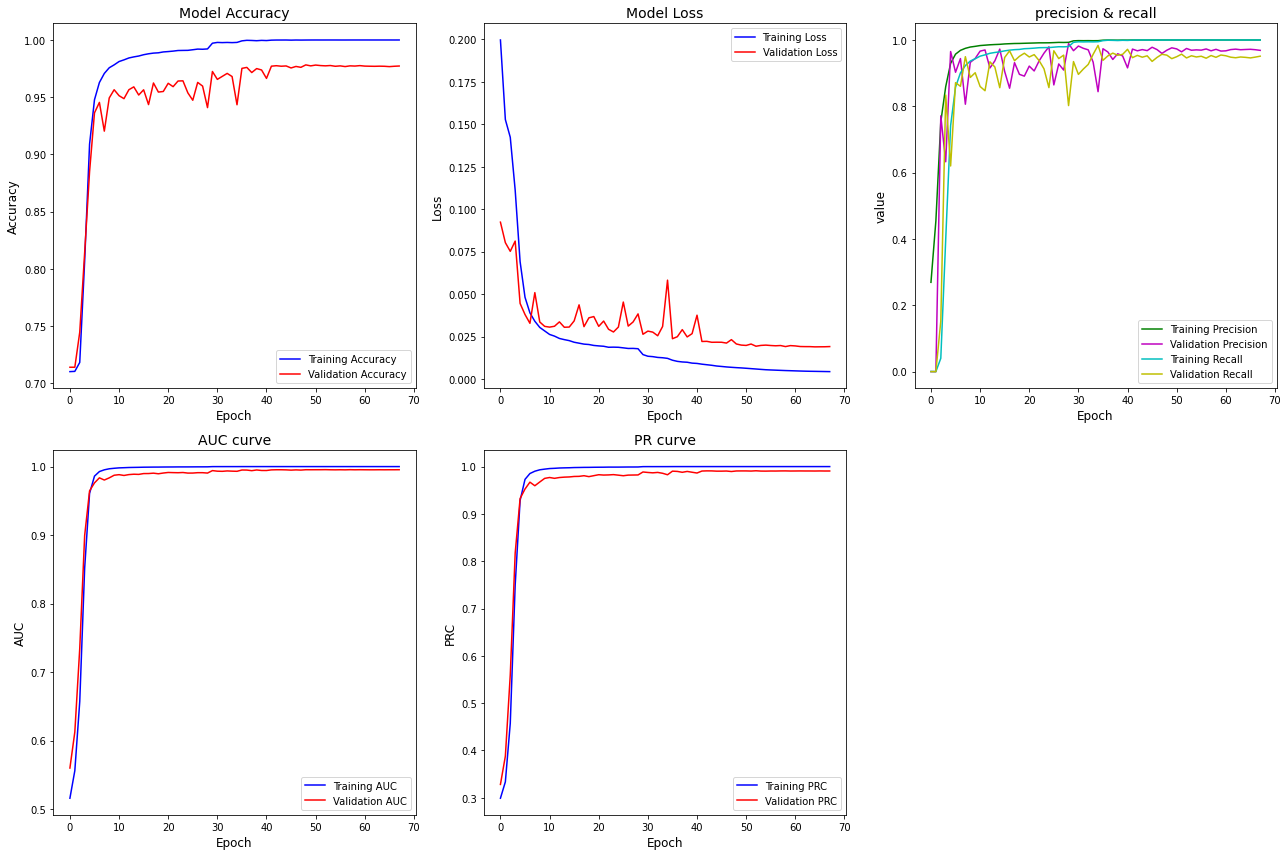


模型已保存为 'matrix_invertibility_detector_v2.h5'

案例: 单位矩阵
预测概率: 0.9991 -> 可逆
实际行列式: 1.0000 -> 可逆
预测结果: 正确

案例: 全1矩阵
预测概率: 0.0036 -> 不可逆
实际行列式: 0.0000 -> 不可逆
预测结果: 正确


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


def gf2_rank_bitpack(matrix):
    """
    计算n×n二进制矩阵在GF(2)上的秩 using bit packing.
    """
    n = matrix.shape[0]
    # 将每一行转换为一个整数（使用足够多的位）
    rows = []
    for i in range(n):
        row_val = 0
        for j in range(n):
            if matrix[i, j] == 1:
                # 注意：这里需要根据矩阵大小调整位偏移
                row_val |= (1 << (n - 1 - j))
        rows.append(row_val)

    rank = 0
    for col in range(n):
        bit_mask = 1 << (n - 1 - col)  # 检查当前列对应的位
        pivot = -1
        for r in range(rank, n):
            if rows[r] & bit_mask:
                pivot = r
                break
        if pivot == -1:
            continue
        # 交换行
        rows[rank], rows[pivot] = rows[pivot], rows[rank]
        # 消去其他行
        for r in range(rank + 1, n):
            if rows[r] & bit_mask:
                rows[r] ^= rows[rank]
        rank += 1
    return rank


def generate_dataset(num_samples=50000):
    """生成32×32 0-1矩阵及其可逆性标签"""
    print(f"正在生成 {num_samples} 个32×32矩阵...")
    start_time = time.time()

    matrices = np.random.randint(0, 2, size=(num_samples, 32, 32))

    # 分批计算GF(2)秩，避免内存溢出
    batch_size = 256
    labels = np.zeros(num_samples, dtype=np.int32)

    for i in range(0, num_samples, batch_size):
        end_idx = min(i + batch_size, num_samples)
        batch = matrices[i:end_idx]
        # 对于每个矩阵，计算GF(2)秩，如果秩为32则可逆
        ranks = [gf2_rank_bitpack(mat) for mat in batch]
        labels[i:end_idx] = (np.array(ranks) == 32).astype(np.int32)

    duration = time.time() - start_time
    print(f"数据集生成完成，耗时: {duration:.2f}秒")

    # 计算可逆矩阵比例
    invertible_ratio = np.mean(labels)
    print(f"可逆矩阵比例: {invertible_ratio:.2%}")

    return matrices, labels



# 生成16×16数据集
# def generate_dataset(num_samples=50000):
#     """生成16×816 0-1矩阵及其可逆性标签"""
#     print(f"正在生成 {num_samples} 个32×32矩阵...")
#     start_time = time.time()

#     matrices = np.random.randint(0, 2, size=(num_samples, 32, 32))

#     # 分批计算行列式，避免内存溢出
#     batch_size = 256
#     labels = np.zeros(num_samples, dtype=np.int32)

#     for i in range(0, num_samples, batch_size):
#         end_idx = min(i + batch_size, num_samples)
#         batch = matrices[i:end_idx]
#         dets = np.array([np.linalg.det(mat) for mat in batch])
#         labels[i:end_idx] = (dets % 2 == 1).astype(np.int32)

#     duration = time.time() - start_time
#     print(f"数据集生成完成，耗时: {duration:.2f}秒")

#     # 计算可逆矩阵比例
#     invertible_ratio = np.mean(labels)
#     print(f"可逆矩阵比例: {invertible_ratio:.2%}")

#     return matrices, labels


# 改进的数据增强函数
def enhanced_augment_data(matrices, labels):
    """改进的数据增强策略"""
    augmented_matrices = [matrices]
    augmented_labels = [labels]
    n = matrices.shape[1]  # 矩阵大小

    # 行列操作增强
    for _ in range(4):
        # 行交换
        swapped = matrices.copy()
        for i in range(len(matrices)):
            idx1, idx2 = np.random.choice(n, 2, replace=False)
            swapped[i, [idx1, idx2]] = swapped[i, [idx2, idx1]]
        augmented_matrices.append(swapped)
        augmented_labels.append(labels)

        # 列交换
        col_swapped = np.transpose(matrices.copy(), (0, 2, 1))
        for i in range(len(col_swapped)):
            idx1, idx2 = np.random.choice(n, 2, replace=False)
            col_swapped[i, [idx1, idx2]] = col_swapped[i, [idx2, idx1]]
        col_swapped = np.transpose(col_swapped, (0, 2, 1))
        augmented_matrices.append(col_swapped)
        augmented_labels.append(labels)

        # 行加法
        added = matrices.copy()
        for i in range(len(matrices)):
            src_idx, tgt_idx = np.random.choice(n, 2, replace=False)
            added[i, tgt_idx] = (added[i, tgt_idx] + added[i, src_idx]) % 2
        augmented_matrices.append(added)
        augmented_labels.append(labels)

    # 生成难例样本
    print("生成难例样本...")
    hard_samples = []
    hard_labels = []

    # 从实际数据中选择FN样本（假负例）进行增强
    fn_indices = np.where(labels == 1)[0]
    for idx in fn_indices[:2000]:
        mat = matrices[idx].copy()
        for _ in range(2):
            i, j = np.random.randint(0, n), np.random.randint(0, n)
            mat[i, j] = 1 - mat[i, j]
        hard_samples.append(mat)
        hard_labels.append(1)

    augmented_matrices.append(np.array(hard_samples))
    augmented_labels.append(np.array(hard_labels))

    # 添加特殊奇异模式矩阵
    print("添加特殊奇异模式...")
    special_non_invertible = []

    # 全零行/列
    for _ in range(500):
        mat = np.random.randint(0, 2, (32, 32))
        if np.random.rand() > 0.5:
            mat[np.random.randint(0, 32)] = 0  # 全零行
        else:
            mat[:, np.random.randint(0, 32)] = 0  # 全零列
        special_non_invertible.append(mat)

    # 相同行/列
    for _ in range(500):
        mat = np.random.randint(0, 2, (32, 32))
        if np.random.rand() > 0.5:
            row1, row2 = np.random.choice(32, 2, replace=False)
            mat[row2] = mat[row1]  # 相同行
        else:
            col1, col2 = np.random.choice(32, 2, replace=False)
            mat[:, col2] = mat[:, col1]  # 相同列
        special_non_invertible.append(mat)

    # 线性相关行/列
    for _ in range(500):
        mat = np.random.randint(0, 2, (32, 32))
        if np.random.rand() > 0.5:
            row1, row2 = np.random.choice(32, 2, replace=False)
            mat[row2] = (mat[row1] + mat[np.random.choice(32)]) % 2  # 行线性相关
        else:
            col1, col2 = np.random.choice(32, 2, replace=False)
            mat[:, col2] = (mat[:, col1] + mat[:, np.random.choice(32)]) % 2  # 列线性相关
        special_non_invertible.append(mat)

    augmented_matrices.append(np.array(special_non_invertible))
    augmented_labels.append(np.zeros(len(special_non_invertible)))

    augmented_matrices = np.vstack(augmented_matrices)
    augmented_labels = np.concatenate(augmented_labels)

    return augmented_matrices, augmented_labels


# 改进模型
def create_enhanced_model_v2():
    inputs = layers.Input(shape=(32, 32, 1))

    # 初始卷积块
    x = layers.Conv2D(128, (5, 5), padding='same', activation='swish')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # 8×8 → 4×4

    # 残差块
    def residual_block(x, filters):
        shortcut = x
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='swish',kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='swish',kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        return layers.add([x, shortcut])

    x = residual_block(x, 256)
    x = layers.SpatialDropout2D(0.3)(x)

    # 深度可分离卷积
    x = layers.SeparableConv2D(512, (3, 3), padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # 4×4 → 2×2

    # CBAM注意力机制
    def cbam_block(input_feature, reduction_ratio=8):
        # 通道注意力
        channel = layers.GlobalAveragePooling2D()(input_feature)
        channel = layers.Dense(input_feature.shape[-1] // reduction_ratio,activation='swish')(channel)
        channel = layers.Dense(input_feature.shape[-1],activation='sigmoid')(channel)
        channel = layers.Reshape((1, 1, input_feature.shape[-1]))(channel)
        x = layers.multiply([input_feature, channel])

        # 空间注意力
        spatial = layers.Conv2D(1, (3, 3), padding='same',activation='sigmoid')(x)
        return layers.multiply([x, spatial])

    x = cbam_block(x)

    # 特征聚合
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='swish',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)

    # 多尺度特征融合
    y = layers.GlobalMaxPooling2D()(cbam_block(residual_block(inputs, 128)))
    x = layers.concatenate([x, y])

    # 分类头
    x = layers.Dense(256, activation='swish',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    # 改进损失函数
    class BalancedFocalLoss(tf.keras.losses.Loss):
        def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.1):
            super().__init__()
            self.gamma = gamma
            self.alpha = alpha
            self.label_smoothing = label_smoothing

        def call(self, y_true, y_pred):
            y_true = tf.cast(y_true, tf.float32)
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

            # 标签平滑
            y_true = y_true * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing

            cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
            p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
            modulating_factor = tf.pow(1.0 - p_t, self.gamma)
            alpha_factor = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
            loss = alpha_factor * modulating_factor * cross_entropy
            return tf.reduce_mean(loss)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=BalancedFocalLoss(gamma=2.0, alpha=0.3, label_smoothing=0.1),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(name='prc', curve='PR'),
            tf.keras.metrics.SpecificityAtSensitivity(0.5, name='specificity')
        ]
    )

    return model


# 改进/回调函数
def get_enhanced_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_prc',  # 监控PR曲线
            patience=15,
            verbose=1,
            mode='max',
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_prc',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1,
            mode='max'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_prc',
            save_best_only=True,
            save_weights_only=False,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            'training_log.csv',
            separator=',',
            append=False
        ),
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs',
            histogram_freq=1
        )
    ]


# 可视化训练过程
def plot_training_history(history):
    plt.figure(figsize=(18, 12))

    # 准确率曲线
    plt.subplot(2, 3, 1)
    plt.plot(history.history['accuracy'], 'b-', label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy')
    plt.title('Model Accuracy', fontsize=14)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    # 损失曲线
    plt.subplot(2, 3, 2)
    plt.plot(history.history['loss'], 'b-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Model Loss', fontsize=14)
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    # 精度-召回曲线
    plt.subplot(2, 3, 3)
    plt.plot(history.history['precision'], 'g-', label='Training Precision')
    plt.plot(history.history['val_precision'], 'm-', label='Validation Precision')
    plt.plot(history.history['recall'], 'c-', label='Training Recall')
    plt.plot(history.history['val_recall'], 'y-', label='Validation Recall')
    plt.title('precision & recall', fontsize=14)
    plt.ylabel('value', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    # AUC曲线
    plt.subplot(2, 3, 4)
    plt.plot(history.history['auc'], 'b-', label='Training AUC')
    plt.plot(history.history['val_auc'], 'r-', label='Validation AUC')
    plt.title('AUC curve', fontsize=14)
    plt.ylabel('AUC', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    # PR曲线
    plt.subplot(2, 3, 5)
    plt.plot(history.history['prc'], 'b-', label='Training PRC')
    plt.plot(history.history['val_prc'], 'r-', label='Validation PRC')
    plt.title('PR curve', fontsize=14)
    plt.ylabel('PRC', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()


# 评估模型
def evaluate_model(model, X_test, y_test):
    print("\n评估模型性能...")
    results = model.evaluate(X_test, y_test, verbose=0)

    metrics = {
        'loss': results[0],
        'accuracy': results[1],
        'precision': results[2],
        'recall': results[3],
        'auc': results[4],
        'prc': results[5],
        'specificity': results[6]
    }

    print(f"测试损失: {metrics['loss']:.4f}")
    print(f"测试准确率: {metrics['accuracy']:.4f}")
    print(f"测试精度: {metrics['precision']:.4f}")
    print(f"测试召回率: {metrics['recall']:.4f}")
    print(f"测试AUC: {metrics['auc']:.4f}")
    print(f"测试PRC: {metrics['prc']:.4f}")
    print(f"测试特异度: {metrics['specificity']:.4f}")

    # 计算F1分数
    f1 = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'] + 1e-7)
    print(f"测试F1分数: {f1:.4f}")

    # 分类报告
    y_pred = model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)
    print("\n分类报告:")
    print(classification_report(y_test, y_pred, target_names=['不可逆', '可逆']))

    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['不可逆', '可逆'], yticklabels=['不可逆', '可逆'])
    plt.title('Confusion Matrix', fontsize=14)
    plt.ylabel('real label', fontsize=12)
    plt.xlabel('predict label', fontsize=12)
    plt.savefig('confusion_matrix.png', dpi=300)
    plt.show()

    return metrics


def main():
    # 生成数据集
    matrices, labels = generate_dataset(num_samples=50000)

    # 数据增强
    matrices, labels = enhanced_augment_data(matrices, labels)

    # 计算类别权重
    class_ratio = np.mean(labels)
    print(f"增强后数据集可逆矩阵比例: {class_ratio:.2%}")

    # 重塑矩阵为8×8×1
    matrices = matrices.reshape((-1, 32, 32, 1))

    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(
        matrices, labels, test_size=0.2, random_state=42, stratify=labels
    )
    print(f"\n数据集划分:")
    print(f"训练集: {X_train.shape[0]} 样本")
    print(f"测试集: {X_test.shape[0]} 样本")

    # 创建模型
    print("\n创建模型...")
    model = create_enhanced_model_v2()
    model.summary()

    # 训练模型
    print("\n开始训练模型...")
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=256,
        validation_split=0.15,
        verbose=1,
        callbacks=get_enhanced_callbacks(),
        class_weight={0: 1 / (1 - class_ratio), 1: 1 / class_ratio}
    )

    duration = time.time() - start_time
    print(f"模型训练完成，耗时: {duration / 60:.2f} 分钟")

    # 评估模型
    metrics = evaluate_model(model, X_test, y_test)

    # 可视化训练过程
    plot_training_history(history)

    # 保存最终模型
    model.save('matrix_invertibility_detector_v2.h5')
    print("\n模型已保存为 'matrix_invertibility_detector_v2.h5'")

    # 测试特定案例
    test_cases = [
        # 可逆矩阵示例
        {
            "matrix": np.eye(32),
            "name": "单位矩阵"
        },
        # 不可逆矩阵示例
        {
            "matrix": np.ones((32, 32)),
            "name": "全1矩阵"
        },
        # 边界案例
        # {
        #     "matrix": np.array([
        #         [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        #         [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        #         [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        #         [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        #         [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        #         [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        #         [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        #         [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        #         [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        #         [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        #     ]),
        #     "name": "对称矩阵"
        # }
    ]

    for case in test_cases:
        input_data = case["matrix"].reshape(1, 32, 32, 1).astype(np.float32)
        prob = model.predict(input_data, verbose=0)[0][0]
        pred = prob > 0.5
        actual_det = np.linalg.det(case["matrix"])

        print(f"\n案例: {case['name']}")
        print(f"预测概率: {prob:.4f} -> {'可逆' if pred else '不可逆'}")
        print(f"实际行列式: {actual_det:.4f} -> {'可逆' if actual_det % 2 == 1 else '不可逆'}")
        print(f"预测结果: {'正确' if pred == (actual_det != 0) else '错误'}")


if __name__ == "__main__":
    main()